<center><h1>1-e: Transformers</h1></center>
<center><h2><a href="https://rdfia.github.io/">Course link</a></h2></center>


# Warning :
# Do "File -> Save a copy in Drive" before you start modifying the notebook, otherwise your modifications will not be saved.

In this notebook, we will implement the first Visual Transformer, [ViT](https://arxiv.org/abs/2010.11929). We'll implement a naive version of it, much smaller than the ones described in the paper, and we also won't use complex data augmentation and regularizations. But note that this is important to make transformers work in practice on large-scale dataset.

To get a gist of what is required to make a transformer work in practice, have a look at the [DeiT and CaiT codebase](https://github.com/facebookresearch/deit).

This notebook is a simplified version of the excellent [Timm library](https://github.com/rwightman/pytorch-image-models).

## MOUBARAK Carine 21314682
## ZHANG Zhile 21201131

In [1]:
%pylab inline

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [2]:
import pickle
import math

import numpy as np
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from torchvision import transforms
import torchvision.utils as vutils
import torchvision
from PIL import Image
import matplotlib.pyplot as plt

Let's load the MNIST dataset:

In [3]:
transform = transforms.Compose([
  transforms.ToTensor()
])

train_dataset = torchvision.datasets.MNIST('.', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST('.', train=False, download=True, transform=transform)


train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128)

... and visualize!

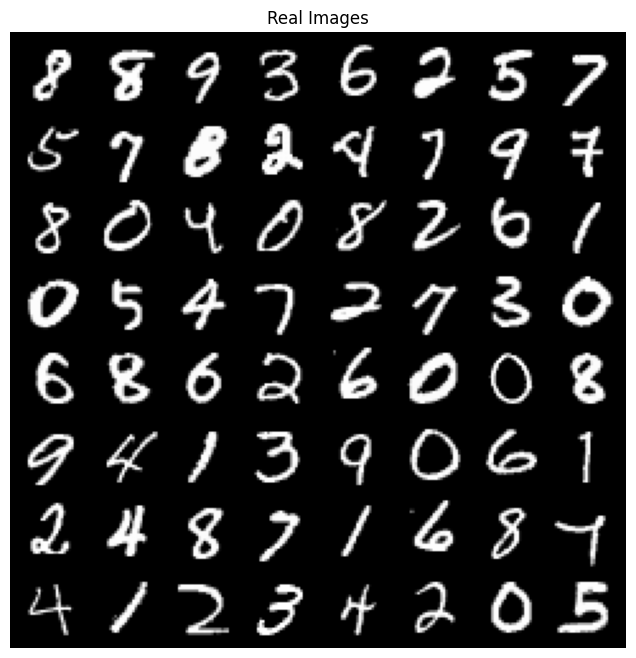

In [4]:
real_batch = next(iter(train_loader))
plt.figure(figsize=(8,8))
plt.axis("off")
plt.title("Real Images")
plt.imshow(vutils.make_grid(real_batch[0][:64], normalize=True).permute(1,2,0))
plt.show()

# Here is the general architecture of the ViT model
## The architecture includes:
- A step for splitting the image into disjoint patches with a linear projection of the patches
- Positional encoding to capture the absolute spatial information of each patch in the image
- The addition of a "[CLS]" token, initialized randomly and learned during training
- A transformer encoder that learns the representation of each token
- A classification head that performs class prediction from the re-embedded [CLS] token at the output of the encoder

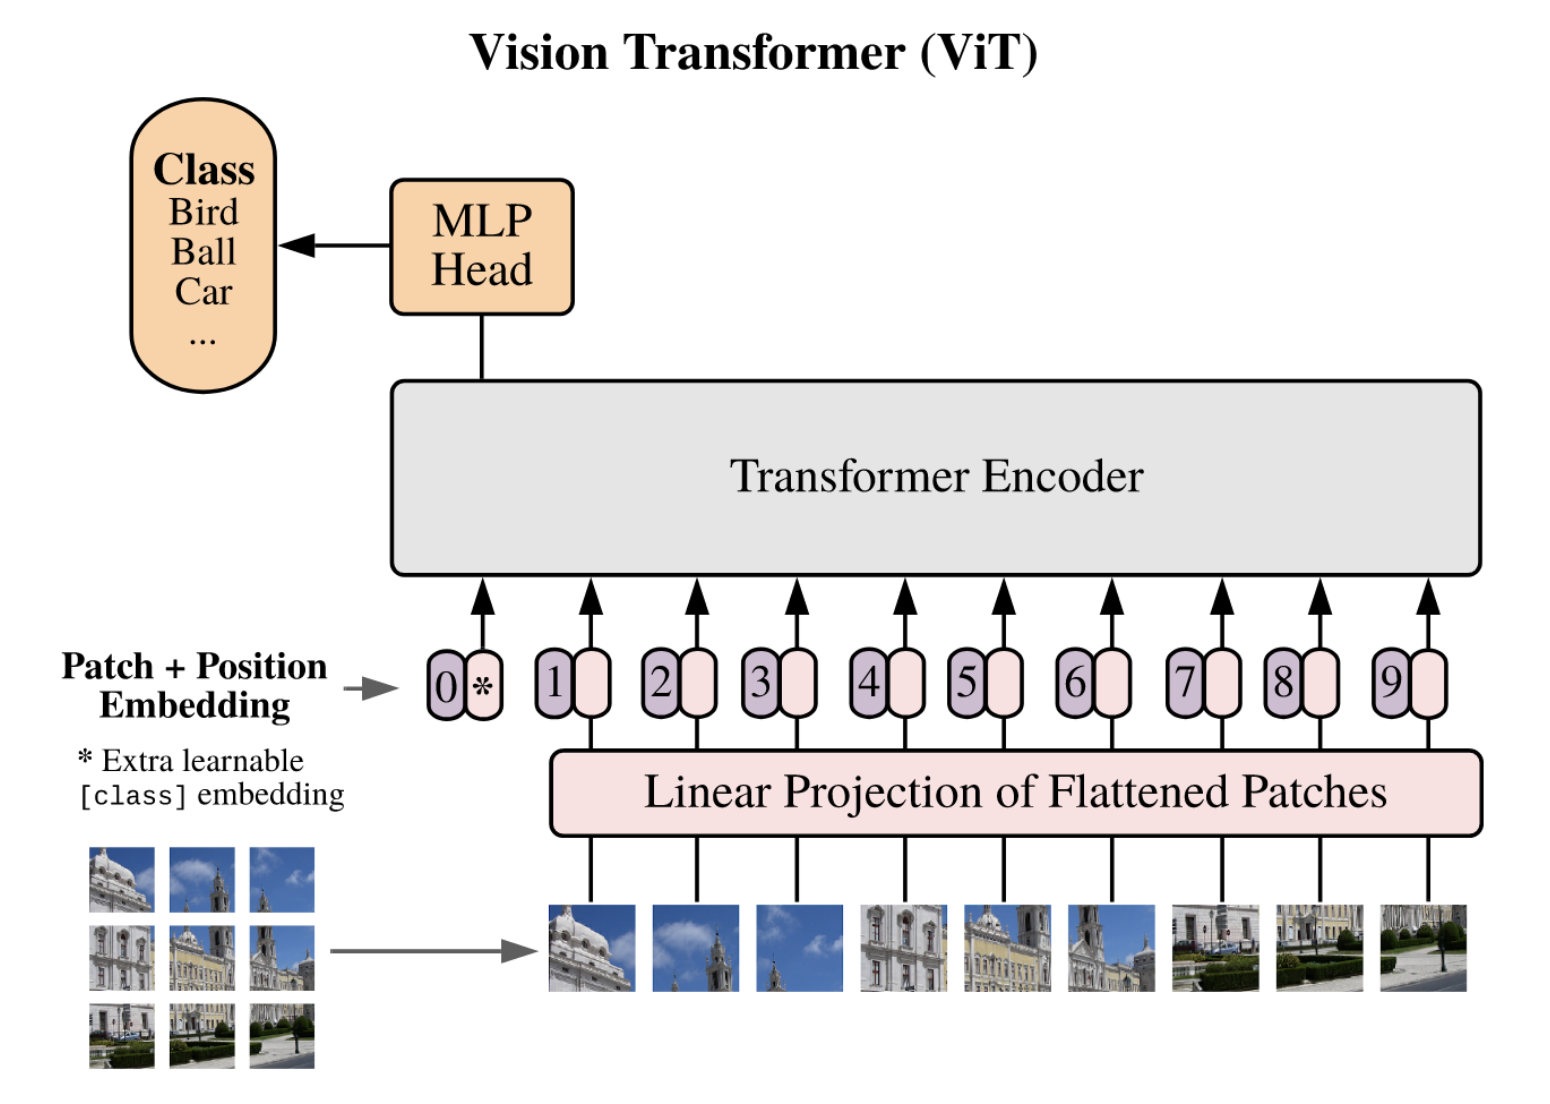

# Linear Projection of flattened patches

**Q1**:
First, we need to code the patch embedding. In NLP, it could be using a word2vec embeddings, but we need something different in Computer Vision.

You are going to use a specific 2d convolution to play the role of the so-called "Linear Projection" on the image above and process each patch independently without overlap. Think a bit how you could do that.

Then, you need to manipulate the dimensions of the resulting tensor to get a final tensor of shape `(batch_size, nb_tokens, embedding_dim)`. *Hint: You will need a `view/reshape` and `transpose/permute` operators*.

As usual, remember to check the output shape of your layer by trying with a random tensor!

In [5]:
class PatchEmbed(nn.Module):
  def __init__(self, in_chan=1, patch_size=7, embed_dim=128):
    super().__init__()
    ## FINITTODO
    # Use a conv2d layer to simulate linear projection, kernel size equals to patch size, stride equals to patch size, make sure no overlap
    self.projection = nn.Conv2d(in_chan, embed_dim, kernel_size=patch_size, stride=patch_size)

  def forward(self, x):
    x = self.projection(x)

    #batch_size, channels, height, width)
    B, C, H, W = x.shape
    ## FINITTODO
    x = x.view(B, C, -1)  # flatten as (batch_size, embedding_dim, num_patches)
    # x.shape() -> B, N, C
    x = x.transpose(1, 2) #(batch_size, num_patches, embedding_dim)
    return x


# Transformer encoder

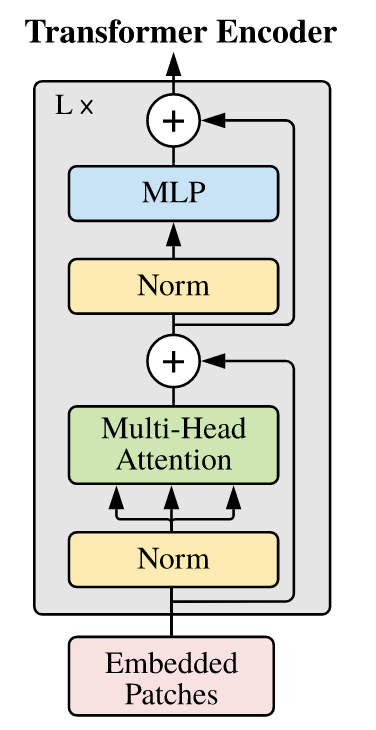

## Q2: MLP

Now we need to build a transformer block. Let's first build the easiest part, the MLP! By now, you should be confident how to code one.

Code a MLP with one hidden layer. Note that the input and output dimensions will be the same. Instead of ReLU, use the activation GELU, which is a slight alternative often used for transformers.

In [6]:
class MLP(nn.Module):
  def __init__(self, in_features, hid_features):
    super().__init__()

    # FINITTODO
    self.fc1 = nn.Linear(in_features, hid_features)
    self.gelu = nn.GELU()
    self.fc2 = nn.Linear(hid_features, in_features)

  def forward(self, x):
    # FINITTODO
    x = self.fc1(x)
    x = self.gelu(x)
    x = self.fc2(x)
    return x


MLP(128, 512)(torch.randn(32, 16, 128)).shape

torch.Size([32, 16, 128])

## Q3: Self-attention

Now we are going to build the famous **Self-Attention**.
- What is the main feature of self-attention, especially compared to its convolutional counterpart. What is its main challenge in terms of computation/memory?
- At first, we are going to only consider the simple case of one head. Write the equations and complete the following code. And don't forget a final linear projection at the end!




In [7]:
class SelfAttention(nn.Module):
  def __init__(self, embed_dim):
    super().__init__()

    # FINITTODO
    self.q = nn.Linear(embed_dim, embed_dim)
    self.k = nn.Linear(embed_dim, embed_dim)
    self.v = nn.Linear(embed_dim, embed_dim)
    self.final_projection = nn.Linear(embed_dim, embed_dim)
        
    self.scale = embed_dim ** -0.5

  def forward(self, x):
    B, N, C = x.shape

    # FINITTODO: compute the Q, K, V
    q = self.q(x)
    k = self.k(x)
    v = self.v(x)

    # FINITTODO: compute the attention matrix using Q and K
    attention = torch.matmul(q, k.transpose(1, 2)) * self.scale  # (B, N, N)

    # FINITTODO: compute the final version using the attention,
    # V
    x = torch.matmul(attention.softmax(dim=-1),v)

    # the final projection
    x =  self.final_projection(x)

    return x


SelfAttention(128)(torch.randn(32, 16, 128)).shape

torch.Size([32, 16, 128])

# Q4 : Multi-head self-attention

Now we need to build a Multi-Heads Self-Attention.
- Write the equations and complete the following code to build a Multi-Heads Self-Attention.
- The total embedding size will be shared equally among all heads.

In [8]:
class MultiHeadsSelfAttention(nn.Module):
  def __init__(self, embed_dim, num_heads):
    super().__init__()

    self.head_dim = embed_dim//num_heads
    self.scale = self.head_dim ** -0.5
    self.num_heads = num_heads
    self.embed_dim = embed_dim  

    self.q = nn.Linear(embed_dim, embed_dim)
    self.k = nn.Linear(embed_dim, embed_dim)
    self.v = nn.Linear(embed_dim, embed_dim)
    self.projection =  nn.Linear(embed_dim, embed_dim)

  def forward(self, x):
    B, N, C = x.shape

    # (B, N, C)
    q = self.q(x)
    k = self.k(x)
    v = self.v(x)

    #print(q.shape, k.shape, v.shape)

    # You need to reshape and permute dimension in a certain manner
    # so that each head (C // num_heads) interact
    # only with its dimensions and not other heads.
    # reshape as (B, num_heads, N, head_dim)
    q = q.view(B, N, self.num_heads, self.head_dim).transpose(1, 2)
    k = k.view(B, N, self.num_heads, self.head_dim).transpose(1, 2)
    v = v.view(B, N, self.num_heads, self.head_dim).transpose(1, 2)

    #print(q.shape, k.shape, v.shape)

    # Try to write at each operation the shape of the tensor if you
    # feel confused.

    # FINITTODO
    #print(k.transpose(-2, -1).shape)
    #print(q.shape)
    attention = torch.matmul(q, k.transpose(-2, -1)) * self.scale # (B, num_heads, N, N)
    weighted_values = torch.matmul(attention.softmax(dim=-1),v)


    weighted_values = weighted_values.transpose(1, 2).contiguous().view(B, N, self.embed_dim) 

    x = self.projection(weighted_values)


    return x


MultiHeadsSelfAttention(6, 2)(torch.randn(32, 16, 6)).shape

torch.Size([32, 16, 6])

# Q5: Transfomer block

Now, we need to build a Transformer **Block** as described in the image below.
- Write the equations and complete the following code.
- For the Layer Normalization, use PyTorch LayerNorm: https://pytorch.org/docs/stable/generated/torch.nn.LayerNorm.html

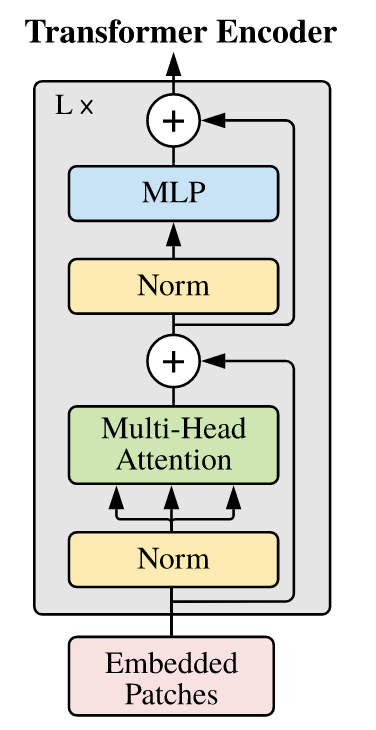

In [9]:
class Block(nn.Module):
  def __init__(self, embed_dim, num_heads=4, mlp_ratio=4):
    super().__init__()

    # FINITTODO
    self.mhsa = MultiHeadsSelfAttention(embed_dim, num_heads)

    self.norm1 = nn.LayerNorm(embed_dim)
    self.norm2 = nn.LayerNorm(embed_dim)

    self.mlp = MLP(embed_dim, int(embed_dim * mlp_ratio))

  def forward(self, x):
    # FINITTODO
    x_residual = x 
    x = self.mhsa(x)  # (B, N, embed_dim)
    x = self.norm1(x + x_residual) 

    x_residual = x 
    x = self.mlp(x)  # (B, N, embed_dim)
    x = self.norm2(x + x_residual)  

    return x

Block(128)(torch.randn(32, 16, 128)).shape

torch.Size([32, 16, 128])

# Q6: Full ViT model

Now you need to build a ViT model based on what you coded in the previous questions. There are additional components that should be coded such as the Class token, Positional embedding and the classification head.

- Explain what is a Class token and why we use it? \\
- Explain whay is the the positional embedding (PE) and why it is important? \\

For PE, you can use a sinusoidal encoding (see below), or fully learned.


### Sinusoidal PE


In [10]:
def get_positional_embeddings(sequence_length, d):
    result = torch.ones(1,sequence_length, d)
    for i in range(sequence_length):
        for j in range(d):
            result[0][i][j] = np.sin(i / (10000 ** (j / d))) if j % 2 == 0 else np.cos(i / (10000 ** ((j - 1) / d)))
    return result

In [11]:
class ViT(nn.Module):
  def __init__(self, embed_dim, nb_blocks, patch_size, nb_classes=10):
    super().__init__()

    num_patches = (28 // patch_size) ** 2

    self.class_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
    self.pos_embed = nn.Parameter(get_positional_embeddings(num_patches + 1, embed_dim), requires_grad=False)
    self.patch_embed = PatchEmbed(patch_size=patch_size, embed_dim=embed_dim)

    blocks = []
    for _ in range(nb_blocks):
      blocks.append(
          Block(embed_dim)
      )
    self.blocks = nn.Sequential(*blocks)

    self.norm = nn.LayerNorm(embed_dim)
    self.head = self.head = nn.Sequential(
            nn.Linear(embed_dim, nb_classes),
            nn.Softmax(dim=-1)
          )

  def forward(self, x):
    x =self.patch_embed(x) ## image to patches

    ## concatenating class token
    B = x.shape[0]
    cls_tokens = self.class_token.expand(B, -1, -1)  # (B, 1, embed_dim)
    x = torch.cat((cls_tokens, x), dim=1) # (B, num_patches + 1, embed_dim)

    ## adding positional embedding
    x = x + self.pos_embed

    ## forward in the transformer
    x = self.blocks(x)

    ## Normalize the output
    x = self.norm(x[:, 0]) 

    output = self.head(x) ## classification output

    return output


ViT(128, 3, 7)(torch.randn(32, 1, 28, 28)).shape

torch.Size([32, 10])

# Q7: Experiment on MNIST!

A quick function to evaluate our model:

In [12]:
@torch.no_grad()
def eval_model(model, loader):
  model.eval()
  acc = 0.
  c = 0

  for x, y in loader:
    x, y = x.cuda(), y.cuda()
    yhat = model(x)

    acc += torch.sum(yhat.argmax(dim=1) == y).cpu().item()
    c += len(x)

  model.train()
  return round(100 * acc / c, 2)

And run! Feel free to try other hyperparameters.

In [13]:
epochs = 10

embed_dim = 32
patch_size = 7
nb_blocks = 2

model = ViT(embed_dim, nb_blocks, patch_size).cuda()

opt = torch.optim.Adam(model.parameters())

train_loss_list =[]
test_loss_list =[]

for epoch in range(epochs):
  train_loss = 0.
  for x, y in train_loader:
    x, y = x.cuda(), y.cuda()

    opt.zero_grad()
    yhat = model(x)
    loss = F.cross_entropy(yhat, y)
    loss.backward()

    opt.step()

    train_loss += loss.item()
  train_loss_list.append(train_loss)

  with torch.no_grad():
    test_loss =0
    for x, y in test_loader:
      x, y = x.cuda(), y.cuda()
      yhat = model(x)
      loss = F.cross_entropy(yhat, y)
      test_loss += loss.item()
    test_loss_list.append(test_loss)


  print(f"--- Epoch {epoch} ---")
  print(f"Train loss: {train_loss / len(train_loader)}")
acc = eval_model(model, test_loader)
print(f"Test accuracy: {acc}")


--- Epoch 0 ---
Train loss: 1.766421331779789
--- Epoch 1 ---
Train loss: 1.5437384312595133
--- Epoch 2 ---
Train loss: 1.523589361959429
--- Epoch 3 ---
Train loss: 1.5154767509208305
--- Epoch 4 ---
Train loss: 1.5093598772467836
--- Epoch 5 ---
Train loss: 1.505289830378632
--- Epoch 6 ---
Train loss: 1.5038150747193457
--- Epoch 7 ---
Train loss: 1.501819073010101
--- Epoch 8 ---
Train loss: 1.4985582442171792
--- Epoch 9 ---
Train loss: 1.4969534497779569
Test accuracy: 96.59


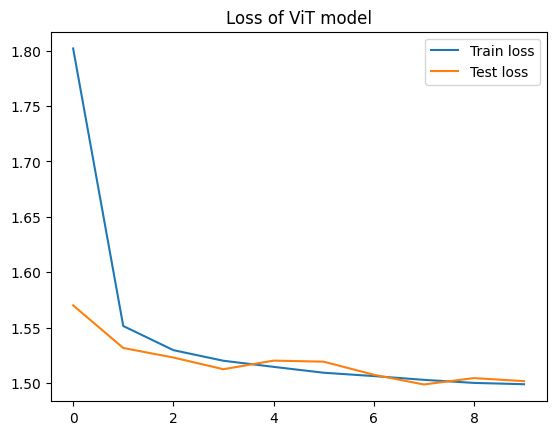

In [15]:
plt.figure()
plt.plot([loss / len(train_loader) for loss in train_loss_list], label='Train loss')
plt.plot([loss / len(test_loader) for loss in test_loss_list], label='Test loss')
plt.title('Loss of ViT model') 
plt.legend()
plt.show()

# Experimental analysis
- Test different hyperparameters and explain how they affect the performance. In particular embed_dim, patch_size, and nb_blocks.
- Comment and discuss the final performance that you get. How to improve it?
-  What is the complexity of the transformer in terms of number of tokens? How you can improve it?

In [18]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

epochs = 10

# Hyperparameter sets to test
embed_dims = [16, 32, 64]     # Test different embedding dimensions
patch_sizes = [4, 7, 14]      # Test different patch sizes
nb_blocks_list = [2, 4, 6]    # Test different number of blocks

# To store the results for plotting
results = {}

# Function to train and test the model with a specific configuration
def train_and_evaluate(embed_dim, patch_size, nb_blocks):
    print(f"Testing: embed_dim={embed_dim}, patch_size={patch_size}, nb_blocks={nb_blocks}")
    
    model = ViT(embed_dim, nb_blocks, patch_size).cuda()
    opt = torch.optim.Adam(model.parameters())

    train_loss_list = []
    test_loss_list = []

    for epoch in range(epochs):
        train_loss = 0.
        for x, y in train_loader:
            x, y = x.cuda(), y.cuda()

            opt.zero_grad()
            yhat = model(x)
            loss = F.cross_entropy(yhat, y)
            loss.backward()

            opt.step()

            train_loss += loss.item()
        train_loss_list.append(train_loss / len(train_loader))

        with torch.no_grad():
            test_loss = 0.
            for x, y in test_loader:
                x, y = x.cuda(), y.cuda()
                yhat = model(x)
                loss = F.cross_entropy(yhat, y)
                test_loss += loss.item()
            test_loss_list.append(test_loss / len(test_loader))

        print(f"--- Epoch {epoch} ---")
        print(f"Train loss: {train_loss / len(train_loader)}")

    # Evaluate test accuracy
    acc = eval_model(model, test_loader)
    print(f"Test accuracy: {acc}")

    # Return the losses and accuracy for plotting
    return train_loss_list, test_loss_list, acc


# Test different embedding dimensions
embed_dim_results = []
for embed_dim in embed_dims:
    train_loss_list, test_loss_list, acc = train_and_evaluate(embed_dim, patch_size=7, nb_blocks=2)
    embed_dim_results.append((embed_dim, train_loss_list, test_loss_list, acc))

# Test different patch sizes
patch_size_results = []
for patch_size in patch_sizes:
    train_loss_list, test_loss_list, acc = train_and_evaluate(embed_dim=32, patch_size=patch_size, nb_blocks=2)
    patch_size_results.append((patch_size, train_loss_list, test_loss_list, acc))

# Test different number of blocks
nb_blocks_results = []
for nb_blocks in nb_blocks_list:
    train_loss_list, test_loss_list, acc = train_and_evaluate(embed_dim=32, patch_size=7, nb_blocks=nb_blocks)
    nb_blocks_results.append((nb_blocks, train_loss_list, test_loss_list, acc))

Testing: embed_dim=16, patch_size=7, nb_blocks=2
--- Epoch 0 ---
Train loss: 1.9472672230145063
--- Epoch 1 ---
Train loss: 1.6199094039290698
--- Epoch 2 ---
Train loss: 1.5688910136090668
--- Epoch 3 ---
Train loss: 1.5513743238408428
--- Epoch 4 ---
Train loss: 1.540626091743583
--- Epoch 5 ---
Train loss: 1.5322263533118436
--- Epoch 6 ---
Train loss: 1.5288587686603765
--- Epoch 7 ---
Train loss: 1.5232417156447227
--- Epoch 8 ---
Train loss: 1.5206519146717943
--- Epoch 9 ---
Train loss: 1.5182493282025302
Test accuracy: 95.01
Testing: embed_dim=32, patch_size=7, nb_blocks=2
--- Epoch 0 ---
Train loss: 1.7870891894867171
--- Epoch 1 ---
Train loss: 1.5499687621842568
--- Epoch 2 ---
Train loss: 1.529788094797114
--- Epoch 3 ---
Train loss: 1.518450744879017
--- Epoch 4 ---
Train loss: 1.512866506952721
--- Epoch 5 ---
Train loss: 1.507696711940806
--- Epoch 6 ---
Train loss: 1.5027134954802264
--- Epoch 7 ---
Train loss: 1.501636949937735
--- Epoch 8 ---
Train loss: 1.49900140792

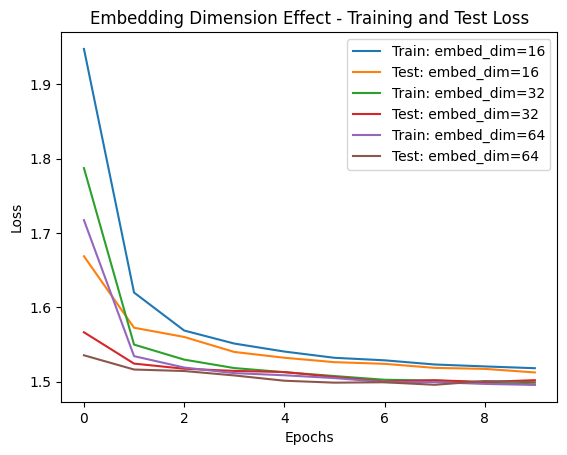

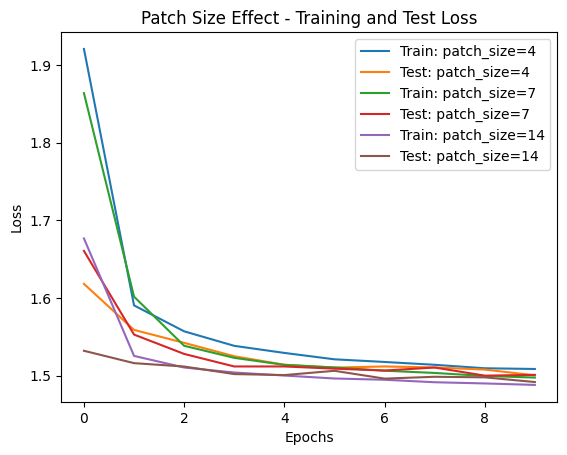

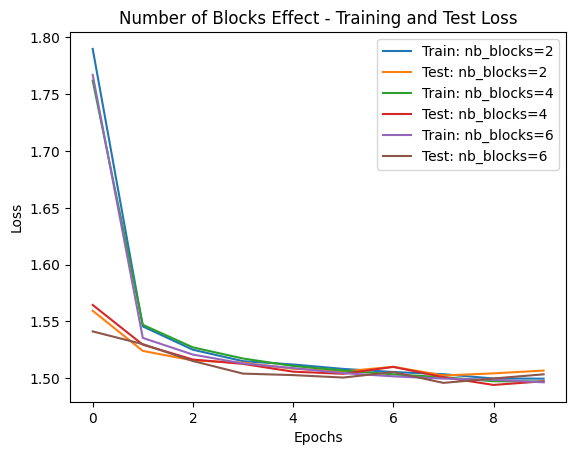

In [19]:
# Plotting results
def plot_results(results, title, x_label):
    for param_value, train_loss_list, test_loss_list, acc in results:
        plt.plot(range(epochs), train_loss_list, label=f"Train: {x_label}={param_value}")
        plt.plot(range(epochs), test_loss_list, label=f"Test: {x_label}={param_value}")

    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title(f'{title} - Training and Test Loss')
    plt.legend()
    plt.show()

# Plot results for each hyperparameter
plot_results(embed_dim_results, title="Embedding Dimension Effect", x_label="embed_dim")
plot_results(patch_size_results, title="Patch Size Effect", x_label="patch_size")
plot_results(nb_blocks_results, title="Number of Blocks Effect", x_label="nb_blocks")

In [20]:
print("Final Accuracies:")
print("Embed_dim Results:")
for embed_dim, _, _, acc in embed_dim_results:
    print(f"Embed_dim={embed_dim}, Accuracy: {acc}")
    
print("\nPatch_size Results:")
for patch_size, _, _, acc in patch_size_results:
    print(f"Patch_size={patch_size}, Accuracy: {acc}")
    
print("\nNb_blocks Results:")
for nb_blocks, _, _, acc in nb_blocks_results:
    print(f"Nb_blocks={nb_blocks}, Accuracy: {acc}")

Final Accuracies:
Embed_dim Results:
Embed_dim=16, Accuracy: 95.01
Embed_dim=32, Accuracy: 95.92
Embed_dim=64, Accuracy: 96.13

Patch_size Results:
Patch_size=4, Accuracy: 96.12
Patch_size=7, Accuracy: 96.1
Patch_size=14, Accuracy: 96.94

Nb_blocks Results:
Nb_blocks=2, Accuracy: 95.46
Nb_blocks=4, Accuracy: 96.43
Nb_blocks=6, Accuracy: 95.73


# Q8: larger transformers

Try to use bigger transformer, for example the ViT-S from the timm library. Test with and without intialization from imagenet.

In [23]:
# !pip install timm

a) Load the model using the timm library without pretrained wewights. Try to apply it directly on a tensor with the same MNIST images resolution. What it is the problem and why we have it? Explain if we have also such problem with CNNs. As ViT takes RGB images, the input tensor should have 3 channels.

In [15]:
import timm
model = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=10)
try:
    model(torch.randn(32, 3, 28, 28))
except AssertionError as err:
    print(err)

Input height (28) doesn't match model (224).


In [16]:
x = torch.randn(32, 1, 28, 28)
x_resized = torch.nn.functional.interpolate(x, size=(224, 224), mode="bilinear")  # 调整大小
x_resized = x_resized.repeat(1, 3, 1, 1).cuda()

print(x_resized.shape)


torch.Size([32, 3, 224, 224])


b) There is a trcik in timm that allows to use pretrained models with different image resolution and number of classes. Try to reload the model to be able to use on MNIST images:

In [17]:
model = timm.create_model('vit_small_patch16_224', img_size=28, pretrained=True)
x = torch.randn(32, 3, 28, 28)
model(x).shape

torch.Size([32, 1000])

In [18]:
model = timm.create_model('vit_small_patch16_224', img_size=28, in_chans=1, pretrained=True)
x = torch.randn(32, 1, 28, 28)
model(x).shape

torch.Size([32, 1000])

c) redo the training with the pretrained ViT-S





In [19]:
@torch.no_grad()
def eval_model2(model, loader, num_channels=1):
  model.eval()
  acc = 0.
  c = 0

  for x, y in loader:
    x, y = x.cuda(), y.cuda()
    x= x.repeat(1,num_channels,1,1)
    yhat = model(x)

    acc += torch.sum(yhat.argmax(dim=1) == y).cpu().item()
    c += len(x)

  model.train()
  return round(100 * acc / c, 2)

In [20]:
model = timm.create_model('vit_base_patch16_224', pretrained=True, pretrained_cfg_overlay={'input_size':(3, 28, 28)}, num_classes=10)
model.cuda()
model.train()

epochs = 20

opt = torch.optim.Adam(model.parameters())


train_loss_liste = []
test_loss_liste = []
train_acc_liste = []
test_acc_liste = []
for epoch in range(epochs):
  model.train()
  train_loss = 0.
  for x, y in train_loader:
    x, y = x.cuda(), y.cuda()

    opt.zero_grad()
    x = x.repeat(1,3,1,1)
    yhat = model(x)
    loss = F.cross_entropy(yhat, y)
    loss.backward()

    opt.step()

    train_loss += loss.item()
  train_loss_liste.append(train_loss/len(train_loader))

  with torch.no_grad():
    test_loss = 0
    for x, y in test_loader:
      x, y = x.cuda(), y.cuda()
      x = x.repeat(1,3,1,1)
      yhat = model(x)
      loss = F.cross_entropy(yhat, y)
      test_loss += loss.item()
    test_loss_liste.append(test_loss/len(test_loader))

    train_acc_liste.append(eval_model2(model, train_loader, num_channels=3))
    test_acc_liste.append(eval_model2(model, test_loader, num_channels=3))

  print(f"--- Epoch {epoch} ---")
  print(f"Train loss: {train_loss / len(train_loader)}")
  print(f"Test loss: {test_loss / len(test_loader)}")
  print(f"Train accuracy: {train_acc_liste[-1]}")
  print(f"Test accuracy: {test_acc_liste[-1]}")



--- Epoch 0 ---
Train loss: 0.9453456183867668
Test loss: 0.4764705700210378
Train accuracy: 83.92
Test accuracy: 84.59
--- Epoch 1 ---
Train loss: 0.4723320101369927
Test loss: 0.41455214536642726
Train accuracy: 86.19
Test accuracy: 86.49
--- Epoch 2 ---
Train loss: 0.4123583651427775
Test loss: 0.3949959202657772
Train accuracy: 86.87
Test accuracy: 87.03
--- Epoch 3 ---
Train loss: 0.37693093971275826
Test loss: 0.3722299049738087
Train accuracy: 88.28
Test accuracy: 87.77
--- Epoch 4 ---
Train loss: 0.35932523784225684
Test loss: 0.37796090326354476
Train accuracy: 88.21
Test accuracy: 87.76
--- Epoch 5 ---
Train loss: 0.3467796378488988
Test loss: 0.33429374800452705
Train accuracy: 89.47
Test accuracy: 88.98
--- Epoch 6 ---
Train loss: 0.3256459100795453
Test loss: 0.3415718169151982
Train accuracy: 89.49
Test accuracy: 88.61
--- Epoch 7 ---
Train loss: 0.31228881977450873
Test loss: 0.3295003694446781
Train accuracy: 89.84
Test accuracy: 89.58
--- Epoch 8 ---
Train loss: 0.3080

In [21]:
acc = eval_model2(model, test_loader,num_channels=3)
print(f"Test accuracy : {acc}")

Test accuracy : 91.01


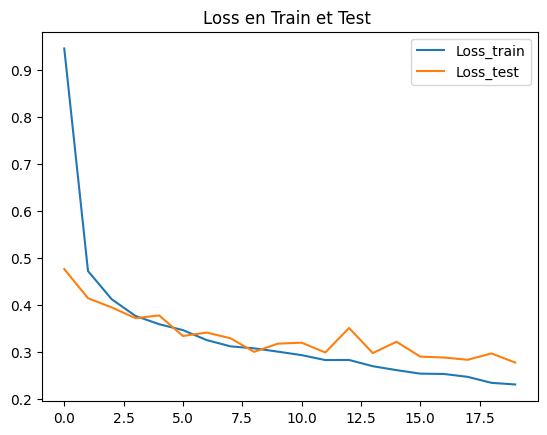

In [22]:
plt.figure()
plt.plot(train_loss_liste, label='Loss_train')
plt.plot(test_loss_liste, label='Loss_test')
plt.title(f'Loss en Train et Test ViT-s')
plt.legend()
plt.show()

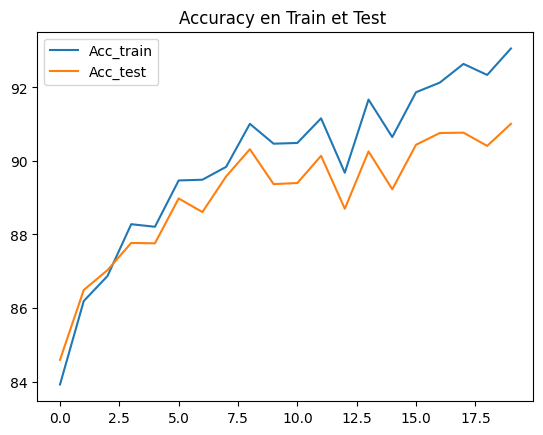

In [23]:
plt.figure()
plt.plot(train_acc_liste, label='Acc_train')
plt.plot(test_acc_liste, label='Acc_test')
plt.title(f'Accuracy en Train et Test ViT-s')
plt.legend()
plt.show()


c) redo the training but with the ViT-S pretrained on ImageNet

In [24]:
model_new = timm.create_model('vit_small_patch16_224', pretrained=True,pretrained_cfg_overlay={'input_size':(3, 28, 28)}, num_classes=10).cuda()

In [25]:
model_new.cuda()
model_new.train()

epochs = 20

opt = torch.optim.Adam(model_new.parameters())


train_loss_liste = []
test_loss_liste = []
train_acc_liste = []
test_acc_liste = []

for epoch in range(epochs):
  model_new.train()
  train_loss = 0.
  for x, y in train_loader:
    x, y = x.cuda(), y.cuda()

    opt.zero_grad()
    x = x.repeat(1,3,1,1)
    yhat = model_new(x)
    loss = F.cross_entropy(yhat, y)
    loss.backward()

    opt.step()

    train_loss += loss.item()
  train_loss_liste.append(train_loss/len(train_loader))

  with torch.no_grad():
    test_loss = 0
    for x, y in test_loader:
      x, y = x.cuda(), y.cuda()
      x = x.repeat(1,3,1,1)
      yhat = model_new(x)
      loss = F.cross_entropy(yhat, y)
      test_loss += loss.item()
    test_loss_liste.append(test_loss/len(test_loader))

    train_acc_liste.append(eval_model2(model_new, train_loader, num_channels=3))
    test_acc_liste.append(eval_model2(model_new, test_loader, num_channels=3))

  print(f"--- Epoch {epoch} ---")
  print(f"Train loss: {train_loss / len(train_loader)}")
  print(f"Test loss: {test_loss / len(test_loader)}")
  print(f"Train accuracy: {train_acc_liste[-1]}")
  print(f"Test accuracy: {test_acc_liste[-1]}")


--- Epoch 0 ---
Train loss: 0.5638692529598025
Test loss: 0.35482812880337994
Train accuracy: 88.41
Test accuracy: 88.3
--- Epoch 1 ---
Train loss: 0.32815756841000715
Test loss: 0.29771320021982434
Train accuracy: 91.03
Test accuracy: 90.17
--- Epoch 2 ---
Train loss: 0.2835467955165072
Test loss: 0.30056446158810507
Train accuracy: 91.66
Test accuracy: 89.96
--- Epoch 3 ---
Train loss: 0.2559792297735397
Test loss: 0.2880052155048787
Train accuracy: 92.52
Test accuracy: 90.49
--- Epoch 4 ---
Train loss: 0.23818602022141028
Test loss: 0.2711293764318092
Train accuracy: 93.29
Test accuracy: 91.18
--- Epoch 5 ---
Train loss: 0.2199890199087576
Test loss: 0.2759045366716536
Train accuracy: 93.74
Test accuracy: 91.11
--- Epoch 6 ---
Train loss: 0.20796516097621368
Test loss: 0.28916618800898897
Train accuracy: 93.99
Test accuracy: 91.06
--- Epoch 7 ---
Train loss: 0.1938168436193517
Test loss: 0.26651479350992396
Train accuracy: 94.66
Test accuracy: 91.52
--- Epoch 8 ---
Train loss: 0.179

In [26]:
acc2 = eval_model2(model_new, test_loader,num_channels=3)
print(f"Test accuracy : {acc2}")

Test accuracy : 91.65


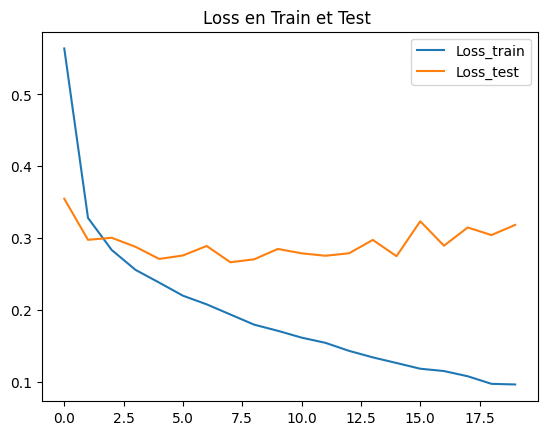

In [27]:
plt.figure()
plt.plot(train_loss_liste, label='Loss_train')
plt.plot(test_loss_liste, label='Loss_test')
plt.title(f'Loss en Train et Test ')
plt.legend()
plt.show()

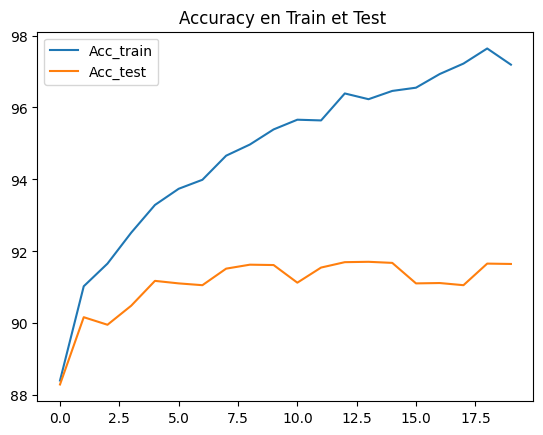

In [28]:
plt.figure()
plt.plot(train_acc_liste, label='Acc_train')
plt.plot(test_acc_liste, label='Acc_test')
plt.title(f'Accuracy en Train et Test ')
plt.legend()
plt.show()


d) Comment the final results and provide some ideas on how to make transformer work on small datasets. You can take inspiration from some recent work.